In [1]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

In [5]:
data = pd.read_csv(r"../data/matchwise_processed.csv")

data.head()

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,team,xg_per_shot,carries_per_pass
0,537,11,20.786734,3.128655,-0.042155,-0.046114,-0.023094,Argentina,0.098427,0.769088
1,659,19,21.512906,2.338624,-0.034995,-0.128787,1.816389,Colombia,0.052009,0.799697
2,378,19,21.140958,2.108844,-0.107044,0.033943,-0.629554,Canada,0.326595,0.759259
3,365,16,23.869265,1.385417,-0.124896,0.032662,0.152638,Uruguay,0.290652,0.794521
4,460,11,21.812680,1.252688,-0.147674,-0.093207,-0.566419,Uruguay,0.068597,0.791304


In [10]:
data.dtypes

passes                    int64
shots                     int64
average_pass_length     float64
ppda                    float64
avg_pass_angle_deep     float64
avg_pass_angle_mid      float64
avg_pass_angle_final    float64
team                     object
xg_per_shot             float64
carries_per_pass        float64
dtype: object

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
for column in data.columns:
    if data[column].dtype != "object":
        print(f"{column} mean: {np.mean(data[column])} and standard deviation: {np.std(data[column])}")

passes mean: 492.54819277108436 and standard deviation: 142.12681242463344
shots mean: 12.831325301204819 and standard deviation: 5.759893065248242
average_pass_length mean: 21.31774774614599 and standard deviation: 2.2632250731548353
ppda mean: 2.625321723335527 and standard deviation: 0.7523337662445927
avg_pass_angle_deep mean: 0.007004988358831624 and standard deviation: 0.14263050647322387
avg_pass_angle_mid mean: -0.04706895264827147 and standard deviation: 0.3124544624462213
avg_pass_angle_final mean: -0.11696605212158662 and standard deviation: 1.6359608007238071
xg_per_shot mean: 0.109024292738363 and standard deviation: 0.06874490142745104
carries_per_pass mean: 0.7935693873788315 and standard deviation: 0.06471248131461153


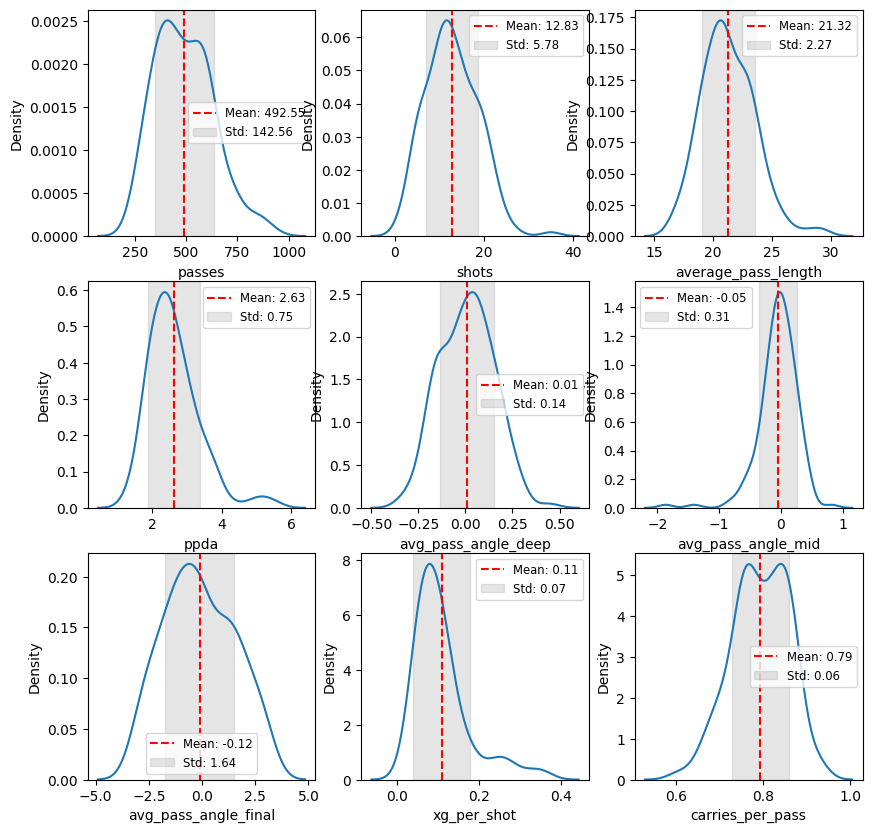

In [19]:
NUMERIC = [column for column in data.columns if data[column].dtype != "object"]

fig, ax = plt.subplots(3, 3, figsize=(10,10))
ax = ax.flatten()

for i, column in enumerate(data[NUMERIC].columns):
    if data[column].dtype != "object":
        sns.kdeplot(data, x=column, ax=ax[i])
        mean_val = data[column].mean()
        std_val = data[column].std()
        
        # Add vertical line for mean
        ax[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        
        # Add shaded area for standard deviation (1 std dev)
        ax[i].axvspan(mean_val - std_val, mean_val + std_val, color='gray', alpha=0.2, label=f'Std: {std_val:.2f}')
        
        # Add a legend to show the values
        ax[i].legend(fontsize='small')
plt.tight_layout
plt.show()

In [ ]:
from sklearn.neighbors import KernelDensity

simul = []

for column in NUMERIC:
    # 1. Reshape to 2D (N samples, 1 feature)
    X = data[column].values.reshape(-1, 1)
    
    # 2. Fit the KDE
    kde = KernelDensity(kernel="gaussian", bandwidth='silverman').fit(X)
    
    # 3. Sample and extract the value
    sample_value = kde.sample(1)[0][0]
    simul.append(sample_value)

print(simul)

[np.float64(561.2146638921993), np.float64(10.338392050031219), np.float64(22.495477092754534), np.float64(2.2267589837599613), np.float64(-0.20281694468048186), np.float64(0.05047120489584317), np.float64(1.4305787948007247), np.float64(-0.14710892411204074), np.float64(0.8786077488363762)]
